# 1. Dataset Structure & Project Scope

# 1.1 PV Dataset Folder Structure

```
PV_Data/
│
├── 2020/
│   ├── Raw Data January.xlsx
│   ├── Raw Data February.xlsx
│   ├── ...
│
├── 2021/
│   ├── MEMR-Raw Data-January.xlsx
│   ├── MEMR-Raw Data-February.xlsx
│   ├── ...
│
├── 2022/
│   ├── MEMR-Raw Data-January.xlsx
│   ├── 2- February/
│   │   ├── Raw Data February.xlsx
```

## 1.2 Analysis Objectives & Planned Visualizations

1. Dataset overview
2. Temperature distribution
3. Temperature over time
4. Daily temperature cycle
5. Monthly variation
6. Example month visualization

# 2. Data Loading

## 2.1 Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
import seaborn as sns

## 2.2 List Current Directory Files

In [ ]:
!ls

PV_Data.zip  sample_data


## 2.3 Extract PV Dataset ZIP File

In [ ]:
!unzip PV_Data.zip

Archive:  PV_Data.zip
   creating: PV_Data/
  inflating: __MACOSX/._PV_Data      
   creating: PV_Data/2022/
  inflating: __MACOSX/PV_Data/._2022  
  inflating: PV_Data/.DS_Store       
  inflating: __MACOSX/PV_Data/._.DS_Store  
   creating: PV_Data/2021/
  inflating: __MACOSX/PV_Data/._2021  
   creating: PV_Data/2020/
  inflating: __MACOSX/PV_Data/._2020  
  inflating: PV_Data/PV_Data.html    
  inflating: __MACOSX/PV_Data/._PV_Data.html  
  inflating: PV_Data/2022/.DS_Store  
  inflating: __MACOSX/PV_Data/2022/._.DS_Store  
   creating: PV_Data/2022/2- February/
  inflating: __MACOSX/PV_Data/2022/._2- February  
  inflating: PV_Data/2022/MEMR-Raw Data-January.xlsx  
  inflating: __MACOSX/PV_Data/2022/._MEMR-Raw Data-January.xlsx  
  inflating: PV_Data/2021/MEMR-Raw Data-May.xlsx  
  inflating: __MACOSX/PV_Data/2021/._MEMR-Raw Data-May.xlsx  
  inflating: PV_Data/2021/MEMR-Raw Data-March.xlsx  
  inflating: __MACOSX/PV_Data/2021/._MEMR-Raw Data-March.xlsx  
  inflating: PV_Data/2021

## 2.4 Inspect Extracted Dataset Folder

In [ ]:
!ls PV_Data

2020  2021  2022


## 2.5 Locate All Excel Data Files

In [ ]:
files = glob.glob("/content/PV_Data/**/*.xlsx", recursive=True)
print("Files found:", len(files))
print(files[:5])

Files found: 24
['/content/PV_Data/2021/MEMR-Raw Data-June.xlsx', '/content/PV_Data/2021/MEMR-Raw Data-May.xlsx', '/content/PV_Data/2021/MEMR-Raw Data-October.xlsx', '/content/PV_Data/2021/MEMR-Raw Data-April.xlsx', '/content/PV_Data/2021/MEMR-Raw Data-November.xlsx']


## 2.6 Read Excel Files into DataFrames

In [ ]:
dfs = []

for i, f in enumerate(files):
    print(f"Loading file {i+1}/{len(files)}:", f)

    df = pd.read_excel(
        f,
        skiprows=3,
        engine="openpyxl"
    )

    dfs.append(df)

Loading file 1/24: /content/PV_Data/2021/MEMR-Raw Data-June.xlsx
Loading file 2/24: /content/PV_Data/2021/MEMR-Raw Data-May.xlsx
Loading file 3/24: /content/PV_Data/2021/MEMR-Raw Data-October.xlsx
Loading file 4/24: /content/PV_Data/2021/MEMR-Raw Data-April.xlsx
Loading file 5/24: /content/PV_Data/2021/MEMR-Raw Data-November.xlsx
Loading file 6/24: /content/PV_Data/2021/MEMR-Raw Data-March.xlsx
Loading file 7/24: /content/PV_Data/2021/MEMR-Raw Data-July.xlsx
Loading file 8/24: /content/PV_Data/2021/MEMR-Raw Data-September.xlsx
Loading file 9/24: /content/PV_Data/2021/Raw Data February.xlsx
Loading file 10/24: /content/PV_Data/2021/Raw Data January.xlsx
Loading file 11/24: /content/PV_Data/2021/MEMR-Raw Data-December.xlsx
Loading file 12/24: /content/PV_Data/2021/MEMR-Raw Data-August.xlsx
Loading file 13/24: /content/PV_Data/2020/Raw Data May.xlsx
Loading file 14/24: /content/PV_Data/2020/Raw Data March.xlsx
Loading file 15/24: /content/PV_Data/2020/Raw Data December.xlsx
Loading file 1

## 2.7 Merge All DataFrames into One Dataset

In [ ]:
data = pd.concat(dfs, ignore_index=True)

print(data.shape)
data.head(5)

(1051276, 25)


,Unnamed: 0,Unnamed: 1,[W/mÂ²],[W/mÂ²].1,[W/mÂ²].2,[W/mÂ²].3,[W/mÂ²].4,[W/mÂ²].5,Irradiation Tilted (kWh/m2),Unnamed: 9,...,[kW].2,Inverter 1 useful time,Inverter 2 useful time,Inverter 3 useful time,Inverter 1 down time,Inverter 2 down time,Inverter 3 down time,Irradiation Tilted (Wh/m2),[dd.mm.YYYY],[HH:MM:SS]
0,01.06.2020 00:00:00,NaN,0.3,0.0,0.0,0.1,0.3,0.1,0.0,16.0,...,0.0,0.0,0.0,0.0,1.0,1.0,1.0,NaN,NaN,NaN
1,01.06.2020 00:01:00,NaN,0.3,0.0,0.0,0.1,0.3,0.1,0.0,16.0,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2,01.06.2020 00:02:00,NaN,0.3,0.0,0.0,0.2,0.3,0.1,0.0,16.0,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3,01.06.2020 00:03:00,NaN,0.3,0.0,0.0,0.2,0.3,0.0,0.0,16.0,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,01.06.2020 00:04:00,NaN,0.3,0.0,0.0,0.1,0.3,0.1,0.0,16.0,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN


#3. Data Cleaning

## 3.1 Clean Column Names

In [ ]:
data.columns = data.columns.str.strip()

print(data.columns)

Index(['Unnamed: 0', 'Unnamed: 1', '[W/mÂ²]', '[W/mÂ²].1', '[W/mÂ²].2',
       '[W/mÂ²].3', '[W/mÂ²].4', '[W/mÂ²].5', 'Irradiation Tilted (kWh/m2)',
       'Unnamed: 9', 'Generated Yield (kWh)', '[Â°C]',
       'Average Module Temp (C°)', '[kW]', '[kW].1', '[kW].2',
       'Inverter 1 useful time', 'Inverter 2 useful time',
       'Inverter 3 useful time', 'Inverter 1 down time',
       'Inverter 2 down time', 'Inverter 3 down time',
       'Irradiation Tilted (Wh/m2)', '[dd.mm.YYYY]', '[HH:MM:SS]'],
      dtype='object')


## 3.2 Rename Important Columns

In [ ]:
data = data.rename(columns={
    "[dd.mm.YYYY]": "date",
    "[HH:MM:SS]": "time",
    "Average Module Temp (C°)": "module_temp"
})

## 3.3 Create Timestamp Feature

In [ ]:
data["Timestamp"] = pd.to_datetime(
    data["date"].astype(str) + " " + data["time"].astype(str),
    format="%d.%m.%Y %H:%M:%S",
    errors="coerce"
)

## 3.4 Convert Module Temperature to Numeric Values

In [ ]:
#extract temperature column
data["module_temp"] = pd.to_numeric(data["module_temp"], errors="coerce")

## 3.5 Inspect Monthly Data Availability

In [ ]:
data["month"].unique()
data["month"].value_counts().sort_index()

,count
month,
6,43200
7,1


## 3.6 Select Relevant Features

In [ ]:
data = data[["Timestamp", "module_temp"]]

data.head()

,Timestamp,module_temp
0,NaT,25.35
1,NaT,25.30
2,NaT,25.23
3,NaT,25.18
4,NaT,25.12


# 4. Dataset Overview & Quality Check

# 4.1 Dataset Shape & Summary Statistics

In [ ]:
#dataset overview
print("Rows:", len(data))
print("Start date:", data["Timestamp"].min())
print("End date:", data["Timestamp"].max())

data["module_temp"].describe()

Rows: 1051276
Start date: 2020-06-01 00:00:00
End date: 2020-07-01 00:00:00


,module_temp
count,544658.000000
mean,34.787162
std,13.268503
min,-6.210000
25%,24.660000
50%,34.880000
75%,44.740000
max,71.990000


## 4.2 Detect Outliers Using Boxplot

The boxplot shows the distribution of
module temperature values.

Most temperatures are concentrated between approximately 25°C and 45°C,
with a median temperature around 35°C. The plot also reveals a possible
outlier below 0°C, indicating an unusually low temperature value that may
require further investigation or cleaning.

<Axes: >

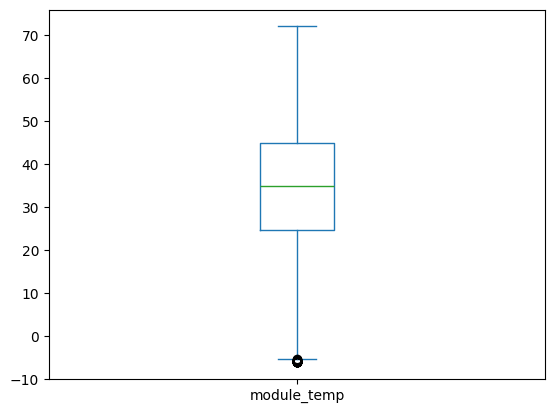

In [ ]:
data["module_temp"].plot.box()

## 4.3 Check Temperature Range

In [ ]:
print(data["module_temp"].max())
print(data["module_temp"].min())

71.99
-6.21


## 4.4 Analyze Missing Values

In [ ]:
print(data.isnull().sum())
print(data["module_temp"].isnull().sum())
missing_pct = data["module_temp"].isnull().mean() * 100 #percentages of missing data
print("missing temperature:", missing_pct, "%")

Timestamp      1008075
module_temp     506618
dtype: int64
506618
missing temperature: 48.19077007370091 %


# 5. Exploratory Data Analysis (EDA)

## 5.1 Temperature Distribution Analysis

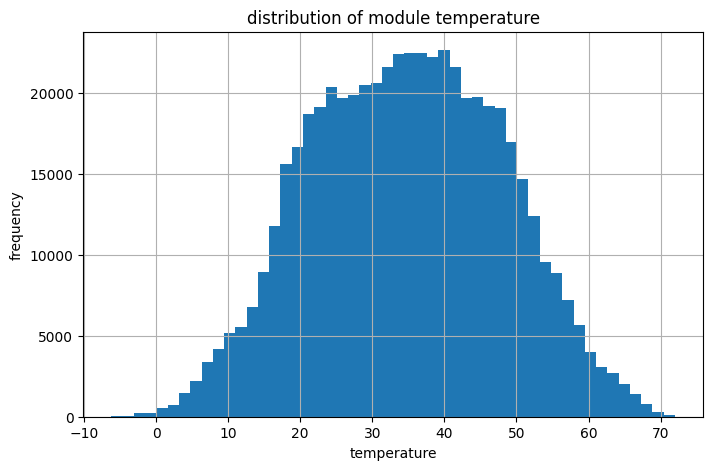

In [ ]:
#temperature distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

data["module_temp"].hist(bins=50)

plt.title("distribution of module temperature")
plt.xlabel("temperature")
plt.ylabel("frequency")

plt.show()

## 5.2 Module Temperature Over Time (Hourly Average)

/tmp/ipykernel_1510/1070523593.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  data_hourly = data.set_index("Timestamp").resample("1H").mean()


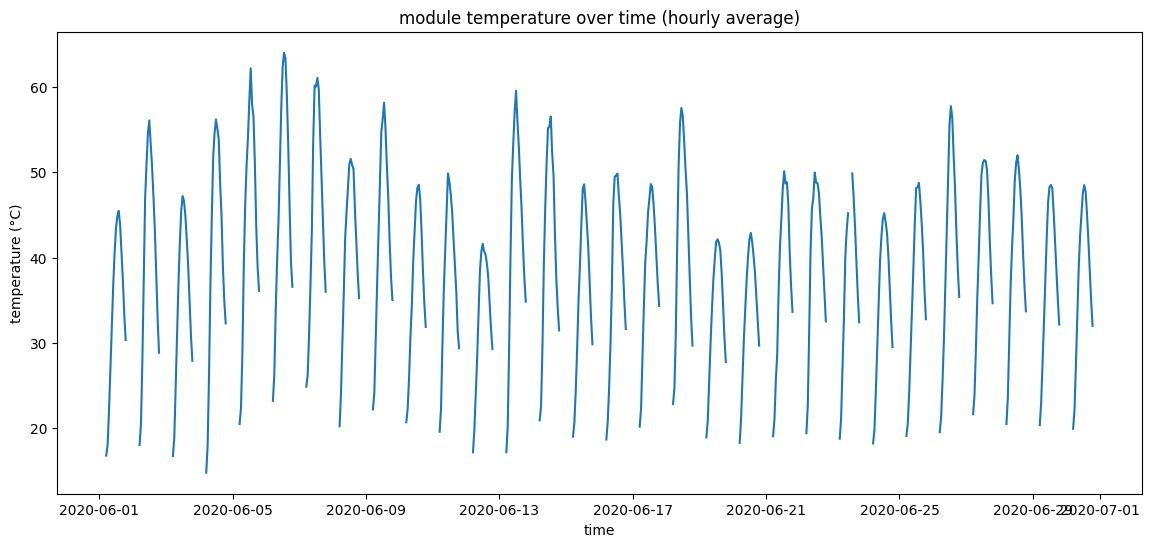

In [ ]:
#temperature over time (hourly averages)
data_hourly = data.set_index("Timestamp").resample("1H").mean()

plt.figure(figsize=(14,6))

plt.plot(data_hourly.index, data_hourly["module_temp"])

plt.title("module temperature over time (hourly average)")
plt.xlabel("time")
plt.ylabel("temperature (°C)")

plt.show()

## 5.3 Daily Module Temperature Cycle

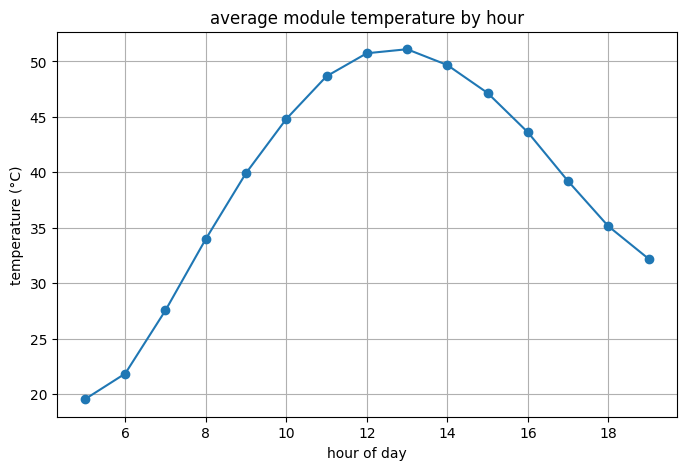

In [ ]:
#daily temperature cycle
data["hour"] = data["Timestamp"].dt.hour

hourly_avg = data.groupby("hour")["module_temp"].mean()

plt.figure(figsize=(8,5))

plt.plot(hourly_avg.index, hourly_avg.values, marker="o")

plt.title("average module temperature by hour")
plt.xlabel("hour of day")
plt.ylabel("temperature (°C)")
plt.grid(True)

plt.show()